C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_36248\3586568940.py:7: DtypeWarning: Columns (17,85,86,87,88,89,90,91,92,93,94,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265) have mixed types. Specify dtype option on import or set low_memory=False.
  china_df = pd.read_csv(
C:\Users\HUAWEI\AppData\Local\Temp\ipykernel_36248\3586568940.py:13: DtypeWarning: Columns (6,7,8,9,10,11,12,13,14,15,16,17,19,22,31,37,38,39,40,56,57,58,

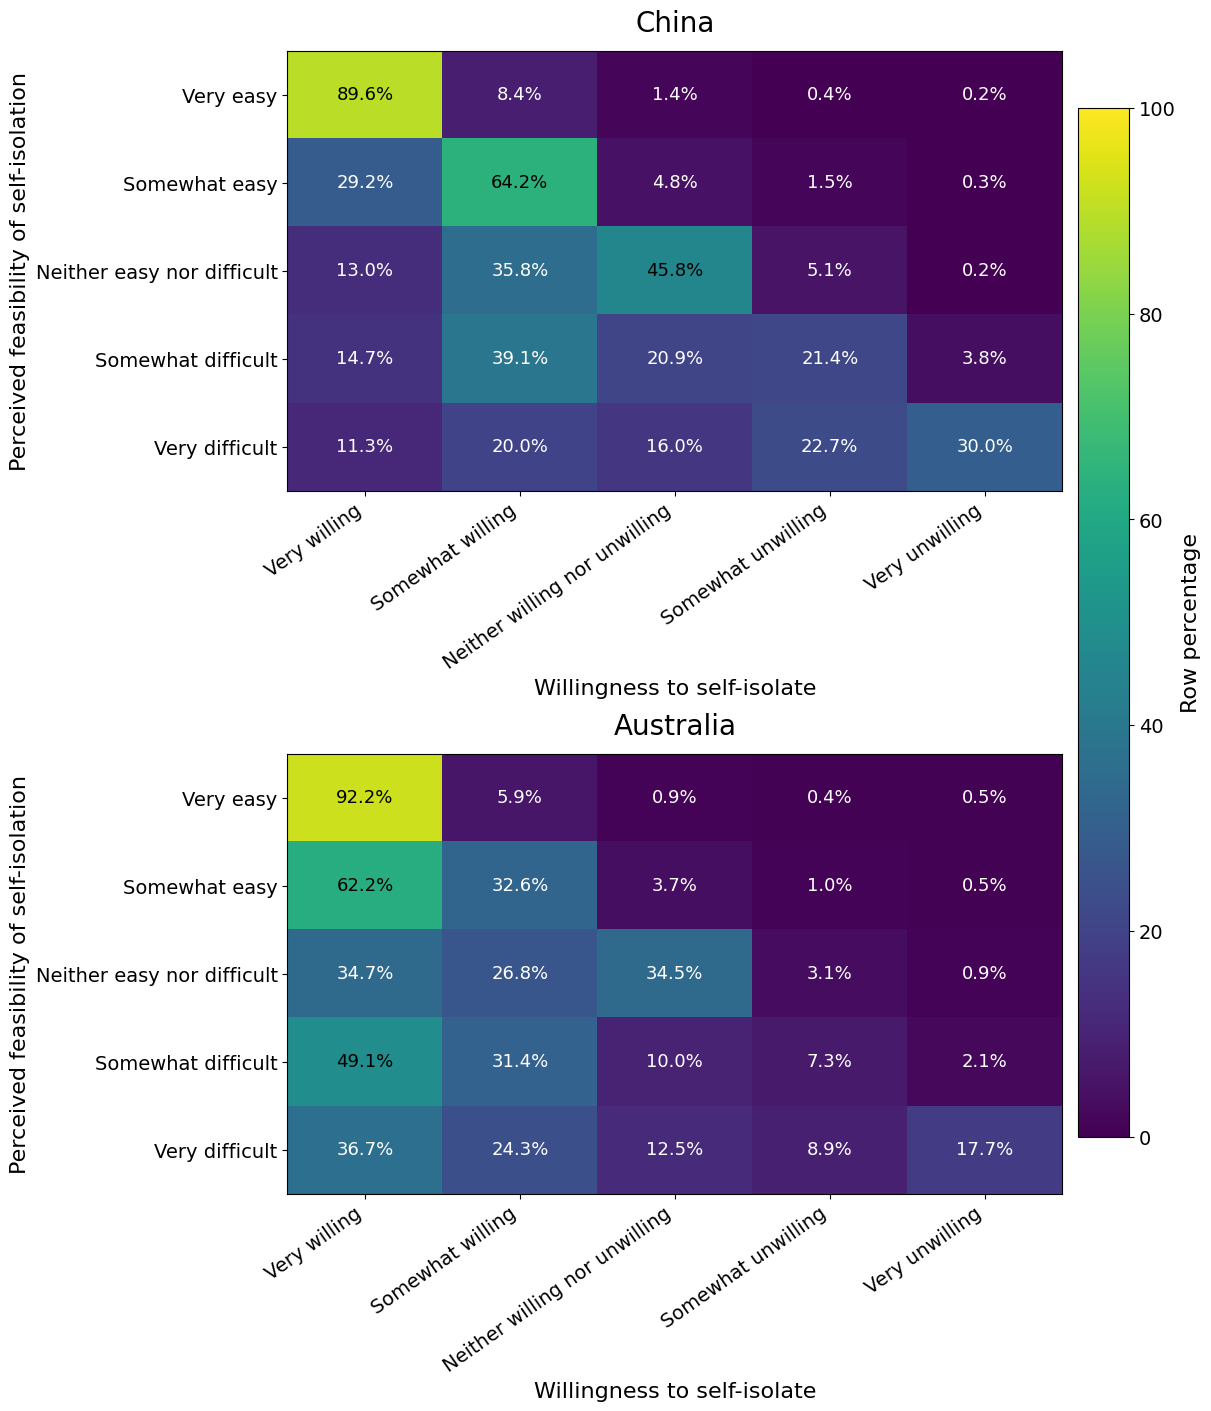

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Read data
china_df = pd.read_csv(
    "../data/raw/china.csv",
    na_values=[" ", "__NA__"],
    keep_default_na=True
)

australia_df = pd.read_csv(
    "../data/raw/australia.csv",
    na_values=[" ", "__NA__"],
    keep_default_na=True
)


# 2. Define variables and category orders
feasibility_col = "i10_health"
willingness_col = "i11_health"

feasibility_order = [
    "Very easy",
    "Somewhat easy",
    "Neither easy nor difficult",
    "Somewhat difficult",
    "Very difficult"
]

willingness_order = [
    "Very willing",
    "Somewhat willing",
    "Neither willing nor unwilling",
    "Somewhat unwilling",
    "Very unwilling"
]


# 3. Create row percentage crosstab
def create_row_percent_crosstab(df):
    # Keep only i10 and i11
    temp_df = df[[feasibility_col, willingness_col]].copy()

    # Remove missing values and Not sure responses
    temp_df = temp_df.dropna(subset=[feasibility_col, willingness_col])
    temp_df = temp_df[
        (temp_df[feasibility_col] != "Not sure")
        & (temp_df[willingness_col] != "Not sure")
    ]

    # Create crosstab
    counts = pd.crosstab(
        temp_df[feasibility_col],
        temp_df[willingness_col]
    )

    # Reorder rows and columns
    counts = counts.reindex(
        index=feasibility_order,
        columns=willingness_order,
        fill_value=0
    )

    # Convert to row percentage
    row_percent = counts.div(counts.sum(axis=1), axis=0) * 100

    return row_percent


china_percent = create_row_percent_crosstab(china_df)
australia_percent = create_row_percent_crosstab(australia_df)


# 4. Plot heatmap function
def plot_heatmap(ax, data, title):
    im = ax.imshow(
        data.values,
        cmap="viridis",
        vmin=0,
        vmax=100,
        aspect="auto"
    )

    ax.set_title(title, fontsize=20, pad=14)

    ax.set_xticks(np.arange(len(willingness_order)))
    ax.set_yticks(np.arange(len(feasibility_order)))

    ax.set_xticklabels(
        willingness_order,
        fontsize=14,
        rotation=35,
        ha="right"
    )
    ax.set_yticklabels(feasibility_order, fontsize=14)

    ax.set_xlabel("Willingness to self-isolate", fontsize=16)
    ax.set_ylabel("Perceived feasibility of self-isolation", fontsize=16)

    # Add percentage labels inside cells
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data.iloc[i, j]
            text_color = "white" if value < 45 else "black"

            ax.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color=text_color,
                fontsize=13
            )

    return im


# 5. Plot China and Australia
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 14),
    constrained_layout=True
)

im1 = plot_heatmap(axes[0], china_percent, "China")
im2 = plot_heatmap(axes[1], australia_percent, "Australia")

# Shared colorbar
cbar = fig.colorbar(
    im2,
    ax=axes,
    shrink=0.9,
    pad=0.02
)

cbar.set_label("Row percentage", fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.savefig(
    "../results/figures/china_australia_feasibility_willingness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()